In [ ]:
## Creating the geometry and saving to text file


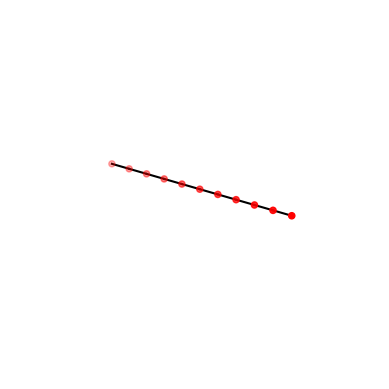

In [11]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=500,
                            youngs_rod=5e3,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

dt = 1e-3
static_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=True,
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=dt,
                                  max_iter=25,
                                  total_time=1.0,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
# env.add_force('damping', eta=1)

geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/horizontal_rod_n11.txt')

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

In [ ]:
fixed_points = np.array([0, 1])
robot = robot.fix_nodes(fixed_points)
stepper = dismech.ImplicitEulerTimeStepper(robot)


EA_increment = robot.stretch_springs.EA[0] / 33
EI_increment = robot.bend_springs.EI[0] / 33

nlenEA =  robot.stretch_springs.EA.size
nlenEI = robot.bend_springs.EI.shape[0]

EA0 = robot.stretch_springs.EA[0]
EI0 = robot.bend_springs.EI[0]
EA_spatial = np.zeros(nlenEA)


def update_EA(robot: dismech.SoftRobot, t: float):
    tstep =int( t/dt)
    # print("tstep",tstep)
    # print("tstep mod 100",tstep // 100 )

    num_active = min((tstep // 100) + 1, nlenEA) # Determines the rate of travel of the air bubble. Right now it is travelling a rod length every 100 timesteps. This needs to grounded in the real flow rate and the air bubble travel rate

    current_active = int(np.sum(EA_spatial))

    # Only update if num_active changed
    if num_active > current_active:

        EA_spatial[current_active:num_active] = 1

        # print("num_active:", num_active)
        # print("EA_spatial:", EA_spatial)

        EA_added = np.zeros(nlenEA)
        EA_added[current_active:num_active] = 1

        EI_added = np.zeros((nlenEI,1))
        EI_added[current_active:num_active] = 1

        robot.stretch_springs.EA += EA_added * EA0
        robot.bend_springs.EI += EI_added * EI0

        # print("EI_added:", EI_added * EI0)

    return robot

stepper.before_step = update_EA

robots, t_arr, f_norms = stepper.simulate()
qs = np.stack([robot.state.q for robot in robots])
vs = np.stack([robot.state.u for robot in robots])
t_arr = np.array(t_arr)

tstep 0
tstep mod 10 0
num_active: 1
EA_spatial: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
EI_added: [[0.00480997 0.00480997]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]]
iter: 1, error: 0.022
iter: 2, error: 0.001
current_time:  0.001
tstep 1
tstep mod 10 0
iter: 1, error: 0.038
iter: 2, error: 0.003
current_time:  0.002
tstep 2
tstep mod 10 0
iter: 1, error: 0.053
iter: 2, error: 0.004
current_time:  0.003
tstep 3
tstep mod 10 0
iter: 1, error: 0.067
iter: 2, error: 0.006
current_time:  0.004
tstep 4
tstep mod 10 0
iter: 1, error: 0.080
iter: 2, error: 0.010
current_time:  0.005
tstep 5
tstep mod 10 0
iter: 1, error: 0.093
iter: 2, error: 0.016
current_time:  0.006
tstep 6
tstep mod 10 0
iter: 1, error: 0.105
iter: 2, error: 0.022
current_time:  0.007
tstep 7
tstep mod 10 0
iter: 1, error: 0.116
iter: 2, error: 0.027
current_time:  0.008
ts

In [68]:
robot.bend_springs.EI.size

18

In [71]:
options = dismech.AnimationOptions(title='Horizontal Rod (N=11))', plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()